In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from bode import (
    compute_analytic_bode,
    compute_empirical_bode,
    make_bode_figure,
)
from era_utils import collect_markov_parameters
from pgf_utils import (
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)

In [2]:
# ── experiment constants ───────────────────────────────────────────────────────
RANDOM_SEED    = 0
N_MARKOV       = 55    # must match the id notebook
N_FFT          = 512   # zero-pad for a smooth empirical curve
DISPLAY_OUTPUT = 0     # output (neuron) index to feature in Bode panels

ERA_PATH     = Path("../../data/era_matrices.npz")
CVA_EM_PATH  = Path("../../data/cva_em_matrices.npz")
FIGURES_PATH = Path("../../figures")
CAPTIONS_PATH = Path("../../captions")

NOTEBOOK_GITHUB_URL = (
    "https://github.com/tahmidazam/gg4/blob/main/notebooks/bode/bode.ipynb"
)

In [3]:
# ── derived: Brain input dimension, ERA and CVA+EM matrices ───────────────────
_b = Brain(random_seed=RANDOM_SEED)
P_DIM = _b.input_dim
del _b

era_data = np.load(ERA_PATH)
A_era, B_era, C_era = era_data["A"], era_data["B"], era_data["C"]

cva_data = np.load(CVA_EM_PATH)
A_cva, B_cva, C_cva = cva_data["A"], cva_data["B"], cva_data["C"]

print(f"p (inputs)  = {P_DIM}")
print(f"ERA    A: {A_era.shape},  B: {B_era.shape},  C: {C_era.shape}")
print(f"CVA+EM A: {A_cva.shape},  B: {B_cva.shape},  C: {C_cva.shape}")

p (inputs)  = 2
ERA    A: (6, 6),  B: (6, 2),  C: (16, 6)
CVA+EM A: (6, 6),  B: (6, 2),  C: (16, 6)


In [4]:
# ── simulation: collect Markov parameters and compute frequency responses ──────
markov = collect_markov_parameters(RANDOM_SEED, P_DIM, N_MARKOV)

freqs, H_emp = compute_empirical_bode(markov, n_fft=N_FFT)
H_era = compute_analytic_bode(A_era, B_era, C_era, freqs)
H_cva = compute_analytic_bode(A_cva, B_cva, C_cva, freqs)

print(f"Frequency grid : {len(freqs)} points in [0, \u03c0]")
print(f"H_emp : {H_emp.shape},  H_era : {H_era.shape},  H_cva : {H_cva.shape}")

Impulse responses:   0%|          | 0/2 [00:00<?, ?it/s]

Frequency grid : 257 points in [0, π]
H_emp : (257, 16, 2),  H_era : (257, 16, 2),  H_cva : (257, 16, 2)


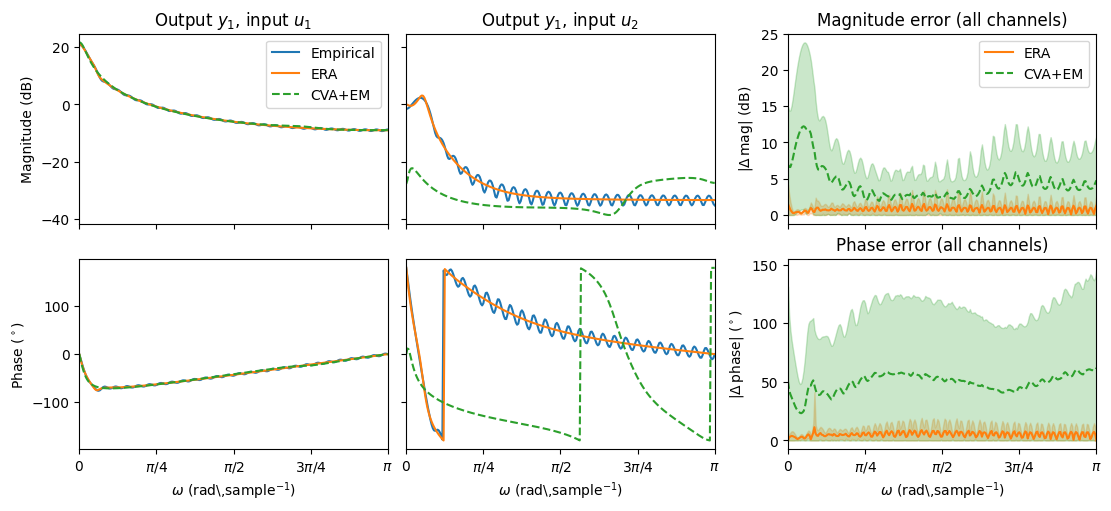

In [5]:
# ── figure: display ────────────────────────────────────────────────────────────
configure_screen()
fig = make_bode_figure(freqs, H_emp, H_era, H_cva, DISPLAY_OUTPUT, figsize=(11, 5))
plt.show()

In [6]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 1.0   # fraction of A4 content width
FIG_HEIGHT_FRAC = 0.24  # fraction of A4 content height

configure_pgf()
fig = make_bode_figure(
    freqs, H_emp, H_era, H_cva, DISPLAY_OUTPUT,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "bode.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/bode.pgf


In [7]:
# ── caption ────────────────────────────────────────────────────────────────────
n_era = A_era.shape[0]
n_cva = A_cva.shape[0]
q = C_era.shape[0]
caption = (
    r"Frequency-response comparison for ERA and CVA+EM identified models. "
    r"Left and centre columns: Bode magnitude (top) and phase (bottom) for "
    r"output $y_{"
    + str(DISPLAY_OUTPUT + 1)
    + r"}$ driven by inputs $u_1$ and $u_2$ respectively, comparing the "
    r"empirical response (discrete Fourier transform of "
    + str(N_MARKOV)
    + r" noise-free Markov parameters, zero-padded to "
    + str(N_FFT)
    + r" points) against the analytic response "
    r"$H(\mathrm{e}^{\mathrm{j}\omega}) = C(\mathrm{e}^{\mathrm{j}\omega}I - A)^{-1}B$ "
    r"for the ERA and CVA+EM models (order $n = "
    + str(n_era)
    + r"$). "
    r"Right column: absolute magnitude error (top) and absolute phase error (bottom), "
    r"shown as mean $\pm$ 1 s.d.\ across all "
    + str(q * P_DIM)
    + r" output--input channels for each method."
)
save_caption(CAPTIONS_PATH / "bode.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/bode.tex
Frequency-response comparison for ERA and CVA+EM identified models. Left and centre columns: Bode magnitude (top) and phase (bottom) for output $y_{1}$ driven by inputs $u_1$ and $u_2$ respectively, comparing the empirical response (discrete Fourier transform of 55 noise-free Markov parameters, zero-padded to 512 points) against the analytic response $H(\mathrm{e}^{\mathrm{j}\omega}) = C(\mathrm{e}^{\mathrm{j}\omega}I - A)^{-1}B$ for the ERA and CVA+EM models (order $n = 6$). Right column: absolute magnitude error (top) and absolute phase error (bottom), shown as mean $\pm$ 1 s.d.\ across all 32 output--input channels for each method.
